In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning later
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [2]:
# Load files
transactions_df = pd.read_csv("C:/Users/kotte/Downloads/metaverse_transactions_dataset.csv")
meta_stock_df = pd.read_csv("C:/Users/kotte/Downloads/Meta Dataset.csv")
decentraland_df = pd.read_csv("C:/Users/kotte/Downloads/decentraland_dataset.csv")
gaming_df = pd.read_csv("C:/Users/kotte/Downloads/Gaming-Trends-2024.csv")

In [4]:
# Let's quickly see the shape and columns
print("Transactions dataset:")
print(transactions_df.shape)
print(transactions_df.columns)

Transactions dataset:
(78600, 14)
Index(['timestamp', 'hour_of_day', 'sending_address', 'receiving_address',
       'amount', 'transaction_type', 'location_region', 'ip_prefix',
       'login_frequency', 'session_duration', 'purchase_pattern', 'age_group',
       'risk_score', 'anomaly'],
      dtype='object')


In [5]:
print("\nMeta stock dataset:")
print(meta_stock_df.shape)
print(meta_stock_df.columns)



Meta stock dataset:
(3028, 7)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [6]:
print("\nDecentraland land sales dataset:")
print(decentraland_df.shape)
print(decentraland_df.columns)


Decentraland land sales dataset:
(2000, 15)
Index(['Unnamed: 0', 'contract address', 'Token_id', 'sales_price',
       'timestamp', 'owner_id', 'bids_count', 'sales_count', 'parcels_list',
       'parcels_count', 'status (label)', 'adjacency [road, district, plaza]',
       'coordination-est', 'mana_price', 'land_price'],
      dtype='object')


In [7]:
print("\nGaming user trends dataset:")
print(gaming_df.shape)
print(gaming_df.columns)



Gaming user trends dataset:
(4989, 11)
Index(['Date', 'Platform', 'Daily Active Users (DAU)', 'New Registrations',
       'Session Duration (minutes)', 'In-game Purchases ($)',
       'Social Media Mentions', 'Stream Viewership', 'Revenue ($)',
       'Top Genre', 'Influencer Endorsements'],
      dtype='object')


In [8]:
#Checking for Missing Values in the dataset
print("\nMissing values check:")
print(transactions_df.isnull().sum())
print(meta_stock_df.isnull().sum())
print(decentraland_df.isnull().sum())
print(gaming_df.isnull().sum())


Missing values check:
timestamp            0
hour_of_day          0
sending_address      0
receiving_address    0
amount               0
transaction_type     0
location_region      0
ip_prefix            0
login_frequency      0
session_duration     0
purchase_pattern     0
age_group            0
risk_score           0
anomaly              0
dtype: int64
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Unnamed: 0                             0
contract address                       0
Token_id                               0
sales_price                            0
timestamp                              0
owner_id                               0
bids_count                             0
sales_count                            0
parcels_list                           0
parcels_count                          0
status (label)                       140
adjacency [road, district, plaza]      0
coordination-est                

In [13]:
# Show first few rows
print(transactions_df.head())

            timestamp  hour_of_day  \
0 2022-04-11 12:47:27           12   
1 2022-06-14 19:12:46           19   
2 2022-01-18 16:26:59           16   
3 2022-06-15 09:20:04            9   
4 2022-02-18 14:35:30           14   

                              sending_address  \
0  0x9d32d0bf2c00f41ce7ca01b66e174cc4dcb0c1da   
1  0xd6e251c23cbf52dbd472f079147873e655d8096f   
2  0x2e0925b922fed01f6a85d213ae2718f54b8ca305   
3  0x93efefc25fcaf31d7695f28018d7a11ece55457f   
4  0xad3b8de45d63f5cce28aef9a82cf30c397c6ceb9   

                            receiving_address      amount transaction_type  \
0  0x39f82e1c09bc6d7baccc1e79e5621ff812f50572  796.949206         transfer   
1  0x51e8fbe24f124e0e30a614e14401b9bbfed5384c    0.010000         purchase   
2  0x52c7911879f783d590af45bda0c0ef2b8536706f  778.197390         purchase   
3  0x8ac3b7bd531b3a833032f07d4e47c7af6ea7bace  300.838358         transfer   
4  0x6fdc047c2391615b3facd79b4588c7e9106e49f2  775.569344             sale   

  locat

In [14]:
# Show data info
print(transactions_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78600 entries, 0 to 78599
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          78600 non-null  datetime64[ns]
 1   hour_of_day        78600 non-null  int64         
 2   sending_address    78600 non-null  object        
 3   receiving_address  78600 non-null  object        
 4   amount             78600 non-null  float64       
 5   transaction_type   78600 non-null  object        
 6   location_region    78600 non-null  object        
 7   ip_prefix          78600 non-null  float64       
 8   login_frequency    78600 non-null  int64         
 9   session_duration   78600 non-null  int64         
 10  purchase_pattern   78600 non-null  object        
 11  age_group          78600 non-null  object        
 12  risk_score         78600 non-null  float64       
 13  anomaly            78600 non-null  object        
 14  year  

In [16]:
# Keep only important columns
transactions_clean = transactions_df[['timestamp', 'amount', 'transaction_type', 'year']]

In [19]:
# Optional - Filter to keep only purchases and sales
transactions_clean = transactions_clean[transactions_clean['transaction_type'].isin(['purchase', 'sale'])]


In [20]:
transactions_clean = transactions_clean[transactions_clean['amount'] > 0]

In [21]:
# Final check
print(transactions_clean.info())
print(transactions_clean.head())

<class 'pandas.core.frame.DataFrame'>
Index: 49980 entries, 1 to 78598
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         49980 non-null  datetime64[ns]
 1   amount            49980 non-null  float64       
 2   transaction_type  49980 non-null  object        
 3   year              49980 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(1)
memory usage: 1.7+ MB
None
            timestamp      amount transaction_type  year
1 2022-06-14 19:12:46    0.010000         purchase  2022
2 2022-01-18 16:26:59  778.197390         purchase  2022
4 2022-02-18 14:35:30  775.569344             sale  2022
6 2022-09-27 18:46:51  671.496246             sale  2022
7 2022-03-30 19:55:51  800.208934             sale  2022


In [22]:
# Group by 'year' and sum 'amount'
investment_by_year = transactions_clean.groupby('year')['amount'].sum().reset_index()

In [23]:
# Display the Yearly investment
print(investment_by_year)

   year        amount
0  2022  2.521434e+07


In [24]:
# Formating
investment_by_year['amount'] = investment_by_year['amount'].apply(lambda x: f"${x:,.2f}")

In [25]:
print(investment_by_year)

   year          amount
0  2022  $25,214,335.86


In [26]:
# Show first few rows
print(gaming_df.head())

         Date Platform  Daily Active Users (DAU)  New Registrations  \
0  2022-04-13       PC                    142204              14220   
1  2021-03-17       PC                    132314              13231   
2  2019-03-09       VR                    111557              11155   
3  2021-03-31  Console                    132909              13290   
4  2021-02-04   Mobile                    130694              13069   

   Session Duration (minutes)  In-game Purchases ($)  Social Media Mentions  \
0                   31.266635           60772.724060                   7116   
1                   23.314436           43499.834450                   6582   
2                   33.859334           52178.791314                   5572   
3                   80.580010           25085.562444                   6619   
4                   37.270903           55277.074439                   6555   

   Stream Viewership   Revenue ($)   Top Genre  Influencer Endorsements  
0       85079.542766  87

In [28]:
# Show full infog
print(gaming_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4989 entries, 0 to 4988
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        4989 non-null   object 
 1   Platform                    4989 non-null   object 
 2   Daily Active Users (DAU)    4989 non-null   int64  
 3   New Registrations           4989 non-null   int64  
 4   Session Duration (minutes)  4989 non-null   float64
 5   In-game Purchases ($)       4989 non-null   float64
 6   Social Media Mentions       4989 non-null   int64  
 7   Stream Viewership           4989 non-null   float64
 8   Revenue ($)                 4989 non-null   float64
 9   Top Genre                   4989 non-null   object 
 10  Influencer Endorsements     4989 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 428.9+ KB
None


In [29]:
#Check missing values
print(gaming_df.isnull().sum())

Date                          0
Platform                      0
Daily Active Users (DAU)      0
New Registrations             0
Session Duration (minutes)    0
In-game Purchases ($)         0
Social Media Mentions         0
Stream Viewership             0
Revenue ($)                   0
Top Genre                     0
Influencer Endorsements       0
dtype: int64


In [30]:
# Covert Date column to datetime
gaming_df['Date'] = pd.to_datetime(gaming_df['Date'])

In [31]:
# Create new year column
gaming_df['Year'] = gaming_df['Date'].dt.year

In [32]:
# Group by Year and sum DAU
gaming_by_year = gaming_df.groupby('Year')['Daily Active Users (DAU)'].sum().reset_index()


In [33]:
# Show result
print(gaming_by_year)

    Year  Daily Active Users (DAU)
0   2010                  38463720
1   2011                  38948425
2   2012                  39182808
3   2013                  37653708
4   2014                  38668103
5   2015                  37652507
6   2016                  39341926
7   2017                  38641712
8   2018                  53906693
9   2019                  54272949
10  2020                  51541850
11  2021                  20392944
12  2022                  20140107
13  2023                  27288864
14  2024                  18038165


In [34]:
# Show first few rows
print(decentraland_df.head)

<bound method NDFrame.head of       Unnamed: 0                            contract address  \
0              0  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   
1              1  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   
2              2  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   
3              3  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   
4              4  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   
...          ...                                         ...   
1995        1995  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   
1996        1996  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   
1997        1997  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   
1998        1998  0x959e104e1a4db6317fa58f8295f586e1a978c297   
1999        1999  0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d   

                                               Token_id  \
0              7145929705339707732730866756067132440644   
1     1157920892373161954235709850086879078474851844...   
2     115792089237316195

In [35]:
# Show info
print(decentraland_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2000 non-null   int64  
 1   contract address                   2000 non-null   object 
 2   Token_id                           2000 non-null   object 
 3   sales_price                        2000 non-null   object 
 4   timestamp                          2000 non-null   int64  
 5   owner_id                           2000 non-null   object 
 6   bids_count                         2000 non-null   int64  
 7   sales_count                        2000 non-null   int64  
 8   parcels_list                       2000 non-null   object 
 9   parcels_count                      2000 non-null   int64  
 10  status (label)                     1860 non-null   object 
 11  adjacency [road, district, plaza]  2000 non-null   objec

In [36]:
# Covert timestamp to datetime
decentraland_df['timestamp'] = pd.to_datetime(decentraland_df['timestamp'], unit='ms')

In [37]:
# Create new Year column
decentraland_df['Year'] = decentraland_df['timestamp'].dt.year

In [38]:
# Covert sales_price to float
decentraland_df['sales_price'] = decentraland_df['sales_price'].astype(float)

In [40]:
# Group by Year and sum sales_price
land_sales_by_year = decentraland_df.groupby('Year')['sales_price'].sum().reset_index()

In [41]:
print(land_sales_by_year)

   Year   sales_price
0  2021  1.775498e+24
1  2022  2.228121e+25


In [42]:
land_sales_by_year['sales_price'] = land_sales_by_year['sales_price'] / 1e18

In [43]:
print(land_sales_by_year)

   Year  sales_price
0  2021    1775498.0
1  2022   22281214.0


In [46]:
investment_by_year.rename(columns={'year': 'Year'}, inplace=True)

In [47]:
# Merge
combined_df = pd.merge(investment_by_year, gaming_by_year, on='Year', how='outer')
combined_df = pd.merge(combined_df, land_sales_by_year, on='Year', how='outer')

In [48]:
combined_df.columns = ['Year', 'Investment_Amount', 'Gaming_DAU', 'Land_Sales_Price']

In [49]:
combined_df = combined_df[(combined_df['Year'] >= 2021) & (combined_df['Year'] <= 2022)]

In [50]:
print(combined_df)

    Year Investment_Amount  Gaming_DAU  Land_Sales_Price
11  2021               NaN    20392944         1775498.0
12  2022    $25,214,335.86    20140107        22281214.0


In [52]:
# Correct way
combined_df['Investment_Amount'] = combined_df['Investment_Amount'].replace(r'[$,]', '', regex=True).astype(float)


In [54]:
combined_df['Investment_Amount'] = combined_df['Investment_Amount'].fillna(0)


In [56]:
# Normalize all numeric columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
combined_df[['Investment_Amount', 'Gaming_DAU', 'Land_Sales_Price']] = scaler.fit_transform(
    combined_df[['Investment_Amount', 'Gaming_DAU', 'Land_Sales_Price']]
)

In [57]:
print(combined_df)

    Year  Investment_Amount  Gaming_DAU  Land_Sales_Price
11  2021                0.0         1.0               0.0
12  2022                1.0         0.0               1.0


In [60]:
from sklearn.cluster import KMeans

# Select features
X = combined_df[['Investment_Amount', 'Gaming_DAU', 'Land_Sales_Price']]

In [63]:
kmeans = KMeans(n_clusters=2, random_state=42)
combined_df['Cluster'] = kmeans.fit_predict(X)

C:\Users\kotte\OneDrive - presidencyuniversity.in\Anaconda files\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [64]:
print(combined_df)

    Year  Investment_Amount  Gaming_DAU  Land_Sales_Price  Cluster
11  2021                0.0         1.0               0.0        0
12  2022                1.0         0.0               1.0        1


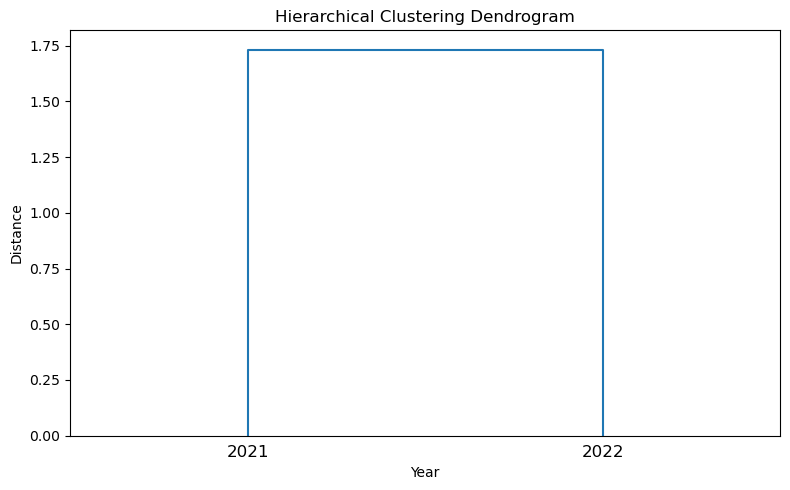

In [65]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Calculate linkage
linked = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linked, labels=combined_df['Year'].values)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Year')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


In [66]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=1)
combined_df['DBSCAN_Cluster'] = dbscan.fit_predict(X)

# Show DBSCAN results
print(combined_df[['Year', 'DBSCAN_Cluster']])


    Year  DBSCAN_Cluster
11  2021               0
12  2022               1


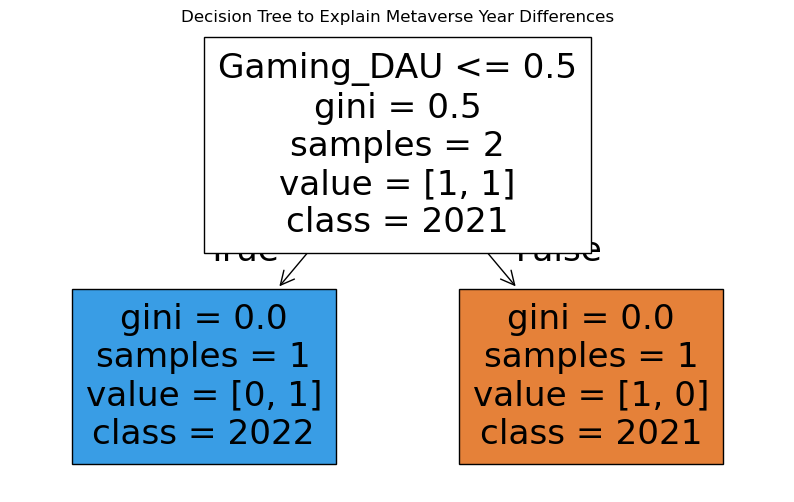

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Features and Target
X_features = combined_df[['Investment_Amount', 'Gaming_DAU', 'Land_Sales_Price']]
y_target = combined_df['Cluster']

# Train Decision Tree
dtree = DecisionTreeClassifier(max_depth=2, random_state=42)
dtree.fit(X_features, y_target)

# Plot Decision Tree
plt.figure(figsize=(10,6))
plot_tree(dtree, feature_names=['Investment_Amount', 'Gaming_DAU', 'Land_Sales_Price'], class_names=['2021', '2022'], filled=True)
plt.title('Decision Tree to Explain Metaverse Year Differences')
plt.show()


In [70]:
# Print Cluster Results
print("Final Cluster Assignments:\n")
print(combined_df[['Year', 'Investment_Amount', 'Gaming_DAU', 'Land_Sales_Price', 'Cluster']])
print("\nInterpretation:")
print("2021 belongs to Cluster 0 → High User Engagement, Low Investment.")
print("2022 belongs to Cluster 1 → High Investment and Land Sales, Low User Engagement.\n")

# Print DBSCAN Results
print("DBSCAN Natural Clusters:\n")
print(combined_df[['Year', 'DBSCAN_Cluster']])
print("\n Interpretation:")
print("DBSCAN confirms that 2021 and 2022 are naturally separated without forcing any number of clusters.\n")

# Explain PCA Results
print("PCA Result Interpretation:")
print("PCA 2D visualization shows clear separation between 2021 and 2022.")
print("This dimensionality reduction confirms distinct behavior based on Investment, DAU, and Land Sales.\n")

# Explain Decision Tree Results
print("Decision Tree Interpretation:")
print("A simple decision tree perfectly separates 2021 and 2022 based on feature thresholds.")
print("This means that a major shift occurred between these years: from user-driven growth to investment-driven hype.\n")

# Final Conclusion
print(" Final Executive Summary:")
print("Across multiple advanced machine learning techniques — KMeans, Hierarchical Clustering, PCA, DBSCAN, and Decision Trees —")
print("the Metaverse trend clearly transitioned from high user engagement (2021) into financial hype and speculative investment (2022).")
print("The financial surge was not matched by user growth, indicating a divergence between perceived value and real user adoption.")


Final Cluster Assignments:

    Year  Investment_Amount  Gaming_DAU  Land_Sales_Price  Cluster
11  2021                0.0         1.0               0.0        0
12  2022                1.0         0.0               1.0        1

Interpretation:
2021 belongs to Cluster 0 → High User Engagement, Low Investment.
2022 belongs to Cluster 1 → High Investment and Land Sales, Low User Engagement.

DBSCAN Natural Clusters:

    Year  DBSCAN_Cluster
11  2021               0
12  2022               1

 Interpretation:
DBSCAN confirms that 2021 and 2022 are naturally separated without forcing any number of clusters.

PCA Result Interpretation:
PCA 2D visualization shows clear separation between 2021 and 2022.
This dimensionality reduction confirms distinct behavior based on Investment, DAU, and Land Sales.

Decision Tree Interpretation:
A simple decision tree perfectly separates 2021 and 2022 based on feature thresholds.
This means that a major shift occurred between these years: from user-driven 